In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/animal-image-classification-5-species")

print("Path to dataset files:", path)

100%|██████████| 5.33M/5.33M [00:00<00:00, 7.53MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/miadul/animal-image-classification-5-species/versions/1


In [2]:
import os

In [3]:
os.listdir(path)

['animals_dataset']

In [4]:
animals_dataset=os.path.join(path,"animals_dataset")

In [5]:
os.listdir(animals_dataset)

['train', 'validation', 'test']

In [6]:
train_path=os.path.join(animals_dataset,"train")
test_path=os.path.join(animals_dataset,"test")
val_path=os.path.join(animals_dataset,"validation")

In [7]:
print(train_path)
print(test_path)
print(val_path)

/root/.cache/kagglehub/datasets/miadul/animal-image-classification-5-species/versions/1/animals_dataset/train
/root/.cache/kagglehub/datasets/miadul/animal-image-classification-5-species/versions/1/animals_dataset/test
/root/.cache/kagglehub/datasets/miadul/animal-image-classification-5-species/versions/1/animals_dataset/validation


In [8]:
print(os.listdir(train_path))
print(os.listdir(test_path))
print(os.listdir(val_path))

['cat', 'dog', 'lion', 'deep', 'cow']
['cat', 'dog', 'lion', 'deep', 'cow']
['cat', 'dog', 'lion', 'deep', 'cow']


In [9]:
len(os.path.join(val_path,"deep"))

119

In [10]:
from tensorflow import keras
from keras import layers

##Lets we are making train,test and validation datasets

In [11]:
#Training Data
train_data=keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(180,180),
    batch_size=8,
    shuffle=True
)

Found 464 files belonging to 5 classes.


In [12]:
#Testing Data
test_data=keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(180,180),
    batch_size=8,
    shuffle=False
)

Found 82 files belonging to 5 classes.


In [13]:
#Validation Data
val_data=keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(180,180),
    batch_size=8,
    shuffle=False
)

Found 83 files belonging to 5 classes.


In [14]:
len(train_data.class_names)

5

#Augmentation

In [151]:
data_augmentation=keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1,0.1) #(height_factor,width_factor) #moves up or down by 10%,or left or right by 10%
])

##Defining Our Model

In [152]:
model=keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(16,3,activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(16,3,activation="relu"),
    layers.MaxPooling2D(2),
    layers.Conv2D(32,3,activation="relu"),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(len(train_data.class_names),activation="softmax")

])

In [153]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [154]:
history=model.fit(train_data,validation_data=val_data,epochs=50)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.2026 - loss: 1.6544 - val_accuracy: 0.1807 - val_loss: 1.6104
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2435 - loss: 1.6099 - val_accuracy: 0.2048 - val_loss: 1.6086
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2522 - loss: 1.5938 - val_accuracy: 0.2289 - val_loss: 1.5450
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2802 - loss: 1.5316 - val_accuracy: 0.2892 - val_loss: 1.5338
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3276 - loss: 1.4874 - val_accuracy: 0.3494 - val_loss: 1.5083
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3254 - loss: 1.4802 - val_accuracy: 0.3735 - val_loss: 1.4325
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3858 - loss: 1.4286 - val_accuracy: 0.3735 - val_loss: 1.5055
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3750 - loss: 1.4118 - val_accuracy: 0.3976 - v

In [155]:
model.save("Fruit_veg.keras")

In [156]:
import matplotlib.pyplot as plt

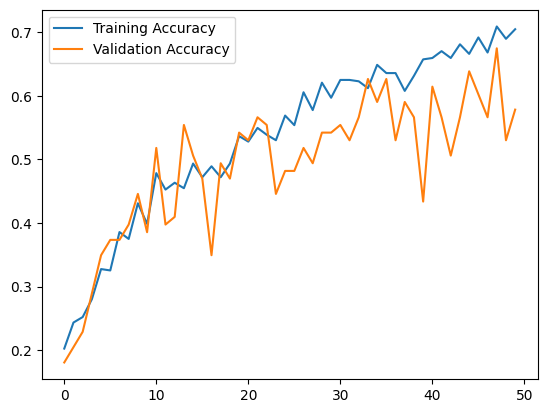

In [157]:
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.legend()
plt.show()

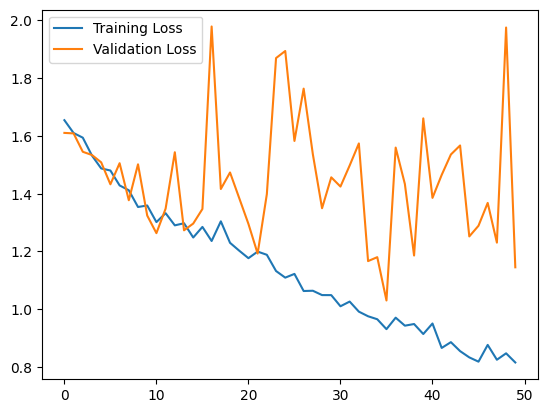

In [158]:
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.legend()
plt.show()

###Lets we can checking our results

In [159]:
import tensorflow as tf

In [160]:
from tensorflow.keras.utils import load_img,img_to_array

In [163]:
#Checking from an image
import numpy as np
cow_path=os.path.join(test_path,"cow")
img_path=os.path.join(cow_path,os.listdir(cow_path)[0])
img=load_img(img_path,target_size=(180,180))
img= img_to_array(img)
img=np.expand_dims(img,axis=0)
pred=model.predict(img)
score=tf.nn.softmax(pred)
prediction=train_data.class_names[np.argmax(score)]
#print(prediction)

confidence=np.max(score)
print(f"Predicted class: {prediction}")
print(f"Confidence Score: {confidence}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted class: cow
Confidence Score: 0.3237564265727997


In [164]:
test_loss,test_acc=model.evaluate(test_data)
print(f"Test Accuracy: {test_acc}")
print(f"Test Loss:{test_loss}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5976 - loss: 1.1409
Test Accuracy: 0.5975610017776489
Test Loss:1.1409434080123901
